In [ ]:
#!/bin/bash
!curl -L -o are-your-employees-burning-out.zip\
  https://www.kaggle.com/api/v1/datasets/download/blurredmachine/are-your-employees-burning-out

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  425k  100  425k    0     0   231k      0  0:00:01  0:00:01 --:--:--  328k


In [ ]:
!unzip /content/are-your-employees-burning-out.zip

Archive:  /content/are-your-employees-burning-out.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/train.csv')
df

,Employee ID,Date of Joining,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,fffe32003000360033003200,2008-09-30,Female,Service,No,2.0,3.0,3.8,0.16
1,fffe3700360033003500,2008-11-30,Male,Service,Yes,1.0,2.0,5.0,0.36
2,fffe31003300320037003900,2008-03-10,Female,Product,Yes,2.0,NaN,5.8,0.49
3,fffe32003400380032003900,2008-11-03,Male,Service,Yes,1.0,1.0,2.6,0.20
4,fffe31003900340031003600,2008-07-24,Female,Service,No,3.0,7.0,6.9,0.52
...,...,...,...,...,...,...,...,...,...
22745,fffe31003500370039003100,2008-12-30,Female,Service,No,1.0,3.0,NaN,0.41
22746,fffe33003000350031003800,2008-01-19,Female,Product,Yes,3.0,6.0,6.7,0.59
22747,fffe390032003000,2008-11-05,Male,Service,Yes,3.0,7.0,NaN,0.72
22748,fffe33003300320036003900,2008-01-10,Female,Service,No,2.0,5.0,5.9,0.52


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22750 entries, 0 to 22749
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee ID           22750 non-null  object 
 1   Date of Joining       22750 non-null  object 
 2   Gender                22750 non-null  object 
 3   Company Type          22750 non-null  object 
 4   WFH Setup Available   22750 non-null  object 
 5   Designation           22750 non-null  float64
 6   Resource Allocation   21369 non-null  float64
 7   Mental Fatigue Score  20633 non-null  float64
 8   Burn Rate             21626 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.6+ MB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Designation,22750.0,2.178725,1.135145,0.0,1.00,2.00,3.00,5.0
Resource Allocation,21369.0,4.481398,2.047211,1.0,3.00,4.00,6.00,10.0
Mental Fatigue Score,20633.0,5.728188,1.920839,0.0,4.60,5.90,7.10,10.0
Burn Rate,21626.0,0.452005,0.198226,0.0,0.31,0.45,0.59,1.0


In [ ]:
df.isnull().sum()

,0
Employee ID,0
Date of Joining,0
Gender,0
Company Type,0
WFH Setup Available,0
Designation,0
Resource Allocation,1381
Mental Fatigue Score,2117
Burn Rate,1124


In [ ]:
df.drop(columns = ['Employee ID','Date of Joining'],inplace = True)
df

,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,Female,Service,No,2.0,3.0,3.8,0.16
1,Male,Service,Yes,1.0,2.0,5.0,0.36
2,Female,Product,Yes,2.0,NaN,5.8,0.49
3,Male,Service,Yes,1.0,1.0,2.6,0.20
4,Female,Service,No,3.0,7.0,6.9,0.52
...,...,...,...,...,...,...,...
22745,Female,Service,No,1.0,3.0,NaN,0.41
22746,Female,Product,Yes,3.0,6.0,6.7,0.59
22747,Male,Service,Yes,3.0,7.0,NaN,0.72
22748,Female,Service,No,2.0,5.0,5.9,0.52


In [ ]:
df['Resource Allocation'].fillna(df['Resource Allocation'].median(), inplace=True)
df['Mental Fatigue Score'].fillna(df['Mental Fatigue Score'].median(), inplace=True)

In [ ]:
df.dropna(subset  = ['Burn Rate'],inplace = True)

In [ ]:
df.isnull().sum()

,0
Gender,0
Company Type,0
WFH Setup Available,0
Designation,0
Resource Allocation,0
Mental Fatigue Score,0
Burn Rate,0


In [ ]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
print(cat_cols)

['Gender', 'Company Type', 'WFH Setup Available']


In [ ]:
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

Gender: ['Female' 'Male']
Company Type: ['Service' 'Product']
WFH Setup Available: ['No' 'Yes']


In [ ]:
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})
df['Company Type'] = df['Company Type'].map({'Service': 0, 'Product': 1})
df['WFH Setup Available'] = df['WFH Setup Available'].map({'No': 0, 'Yes': 1})

In [ ]:
df

,Gender,Company Type,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
0,0,0,0,2.0,3.0,3.8,0.16
1,1,0,1,1.0,2.0,5.0,0.36
2,0,1,1,2.0,4.0,5.8,0.49
3,1,0,1,1.0,1.0,2.6,0.20
4,0,0,0,3.0,7.0,6.9,0.52
...,...,...,...,...,...,...,...
22745,0,0,0,1.0,3.0,5.9,0.41
22746,0,1,1,3.0,6.0,6.7,0.59
22747,1,0,1,3.0,7.0,5.9,0.72
22748,0,0,0,2.0,5.0,5.9,0.52


In [ ]:
print(df[df['Designation'] == 0].shape[0])
print(df[df['Mental Fatigue Score'] == 0].shape[0])
print(df[df['Burn Rate'] == 0].shape[0])

1439
164
272


In [ ]:
num_cols = ['Designation', 'Resource Allocation', 'Mental Fatigue Score', 'Burn Rate']
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_count = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)].shape[0]
    print(f"{col}: {outlier_count} outlier")

Designation: 0 outlier
Resource Allocation: 0 outlier
Mental Fatigue Score: 482 outlier
Burn Rate: 0 outlier


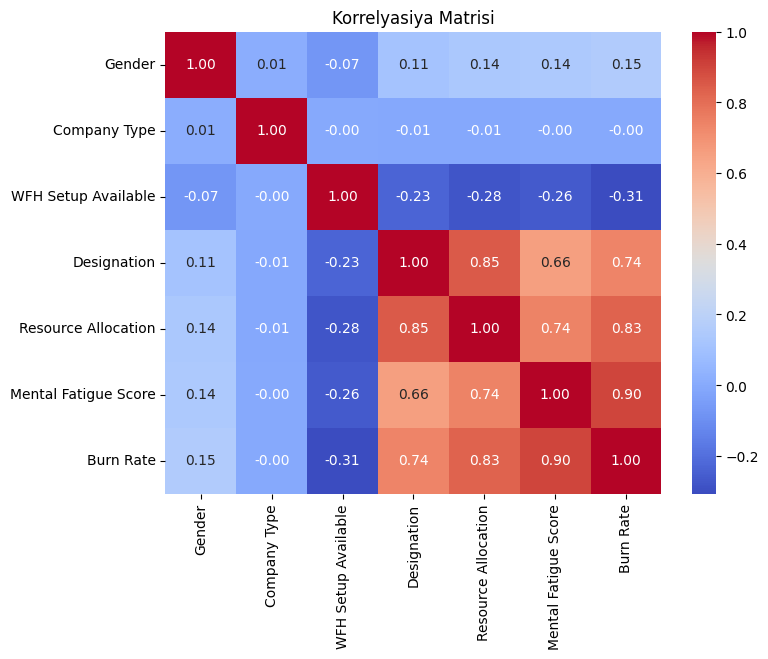

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korrelyasiya Matrisi')
plt.show()

In [ ]:
df.drop(columns=['Company Type'], inplace=True)

In [ ]:
df.columns

Index(['Gender', 'WFH Setup Available', 'Designation', 'Resource Allocation',
       'Mental Fatigue Score', 'Burn Rate'],
      dtype='object')

In [ ]:
df[df['Mental Fatigue Score'] == 0]

,Gender,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
97,1,0,1.0,1.0,0.0,0.0
206,1,1,0.0,1.0,0.0,0.0
232,1,1,0.0,1.0,0.0,0.0
264,0,0,0.0,1.0,0.0,0.0
519,0,0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...
21403,0,0,1.0,2.0,0.0,0.0
21464,0,0,0.0,1.0,0.0,0.0
21639,1,0,1.0,1.0,0.0,0.0
22280,0,1,0.0,1.0,0.0,0.0


In [ ]:
(df[df['Designation'] == 0])

,Gender,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
11,1,1,0.0,1.0,1.8,0.12
32,0,0,0.0,1.0,3.0,0.19
37,0,1,0.0,2.0,3.9,0.19
77,0,1,0.0,1.0,5.9,0.04
82,1,1,0.0,1.0,0.8,0.05
...,...,...,...,...,...,...
22625,0,1,0.0,2.0,3.4,0.26
22661,1,1,0.0,1.0,2.6,0.20
22672,1,0,0.0,1.0,1.0,0.02
22714,0,1,0.0,1.0,3.6,0.15


In [ ]:
(df[df['Burn Rate'] == 0])

,Gender,WFH Setup Available,Designation,Resource Allocation,Mental Fatigue Score,Burn Rate
97,1,0,1.0,1.0,0.0,0.0
206,1,1,0.0,1.0,0.0,0.0
232,1,1,0.0,1.0,0.0,0.0
250,0,0,0.0,1.0,0.5,0.0
264,0,0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...
22320,0,0,0.0,1.0,0.2,0.0
22454,1,1,0.0,1.0,0.8,0.0
22473,1,1,0.0,1.0,0.0,0.0
22513,1,0,1.0,1.0,5.9,0.0


In [ ]:
Q1 = df['Mental Fatigue Score'].quantile(0.25)
Q3 = df['Mental Fatigue Score'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Mental Fatigue Score'] < Q1 - 1.5*IQR) | (df['Mental Fatigue Score'] > Q3 + 1.5*IQR)]
print(outliers['Mental Fatigue Score'].value_counts())

Mental Fatigue Score
0.0    164
0.9     36
1.3     35
1.0     34
1.2     27
0.7     27
0.8     26
1.1     24
0.5     23
0.2     22
0.6     22
0.4     16
0.1     15
0.3     11
Name: count, dtype: int64


In [ ]:
df['Stress_Index'] = df['Mental Fatigue Score'] * df['Resource Allocation']
df['Stress_Index'] = df['Mental Fatigue Score'] * df['Resource Allocation']
df.columns

Index(['Gender', 'WFH Setup Available', 'Designation', 'Resource Allocation',
       'Mental Fatigue Score', 'Burn Rate', 'Stress_Index'],
      dtype='object')

In [ ]:
df[['Stress_Index', 'Burn Rate']].corr()

,Stress_Index,Burn Rate
Stress_Index,1.000000,0.893254
Burn Rate,0.893254,1.000000


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Burn Rate'])
y = df['Burn Rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error,mean_absolute_error

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(f'R2 Score: {r2_score(y_test, y_pred):.4f}')
print(f'MSE: {mean_squared_error(y_test, y_pred):.4f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.4f}')

R2 Score: 0.8704
MSE: 0.0049
MAE: 0.0526


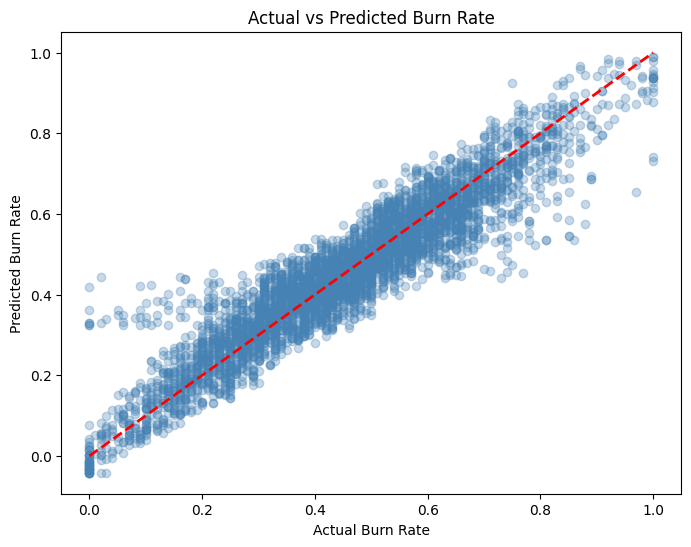

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Burn Rate')
plt.ylabel('Predicted Burn Rate')
plt.title('Actual vs Predicted Burn Rate')
plt.show()

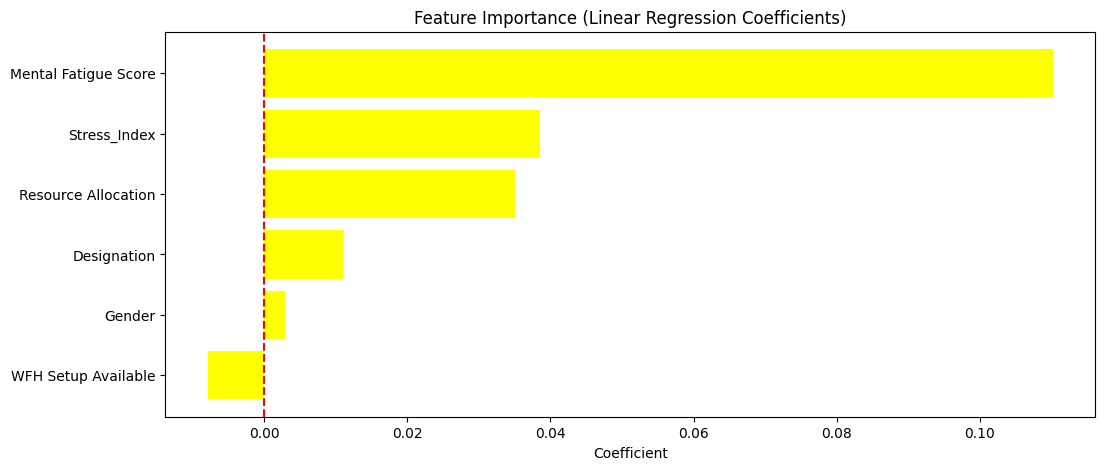

In [ ]:
coefficients  = pd.DataFrame({ 'Feature': X.columns,
                  'Coefficient': model.coef_}).sort_values('Coefficient',ascending = True)
plt.figure(figsize = (12,5))
plt.barh(coefficients['Feature'], coefficients['Coefficient'],color = 'yellow')
plt.xlabel('Coefficient')
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.axvline(x = 0,color = 'red',linestyle = '--')
plt.show()


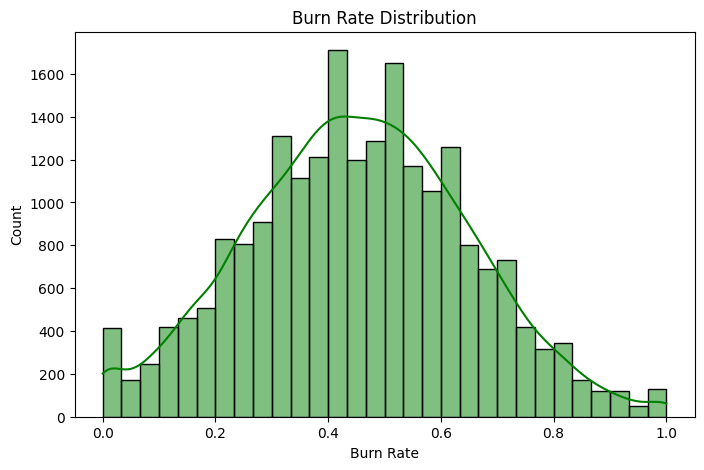

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Burn Rate'], bins=30, kde=True, color='green')
plt.xlabel('Burn Rate')
plt.title('Burn Rate Distribution')
plt.show()

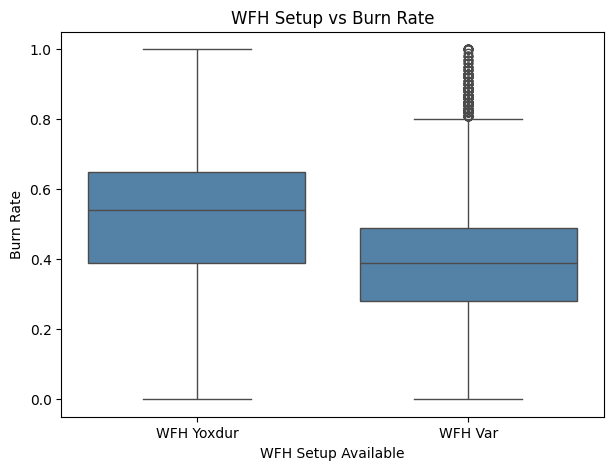

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(x='WFH Setup Available', y='Burn Rate', data=df, color = 'steelblue')
plt.xticks([0, 1], ['WFH Yoxdur', 'WFH Var'])
plt.title('WFH Setup vs Burn Rate')
plt.show()

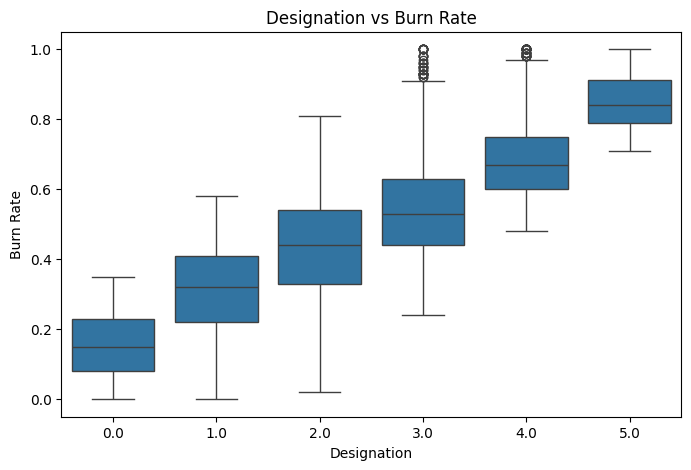

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Designation', y='Burn Rate', data=df)
plt.title('Designation vs Burn Rate')
plt.show()

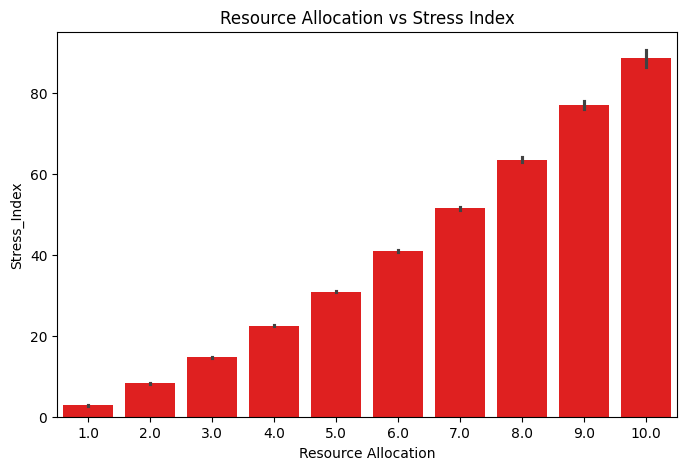

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='Resource Allocation', y='Stress_Index', data=df, color='red')
plt.title('Resource Allocation vs Stress Index')
plt.show()

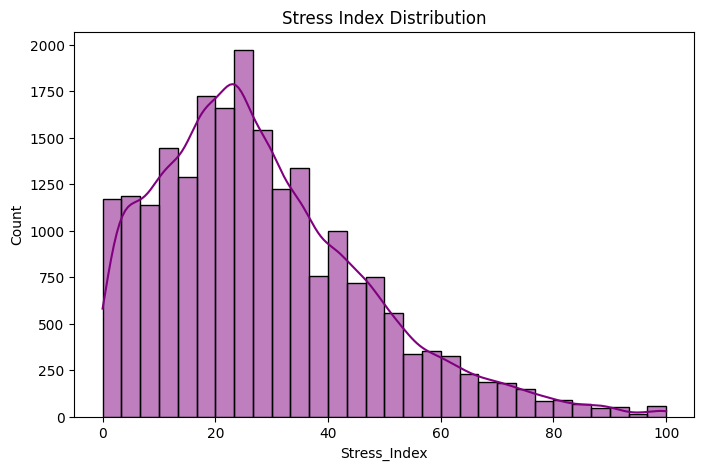

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Stress_Index'], bins=30, kde=True, color='purple')
plt.title('Stress Index Distribution')
plt.show()

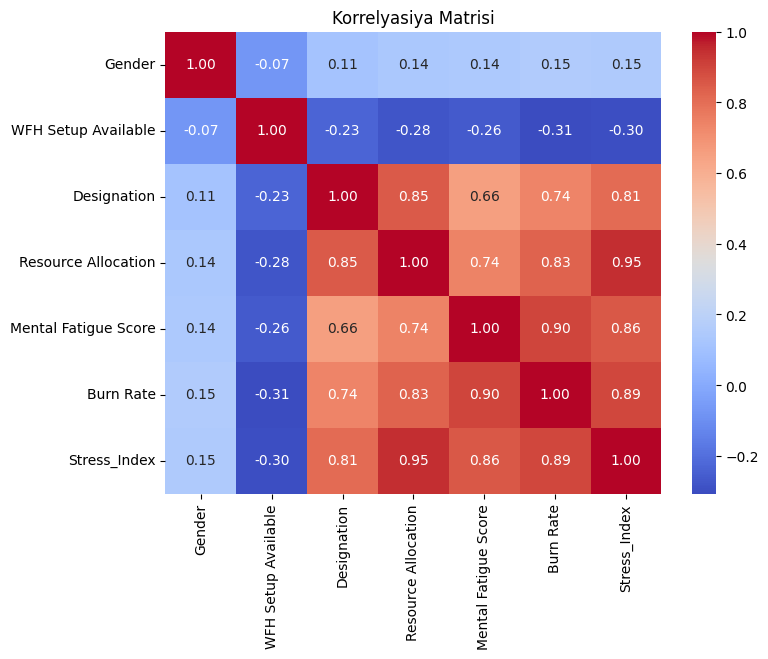

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korrelyasiya Matrisi')
plt.show()